# Cell 1 — Title

# Unemployment Analysis with Python

## Oasis Infobyte Data Science Internship — Task 2

### Objective

Analyze unemployment data in India to identify regional and
time-based trends, with a focus on the impact of the COVID-19
pandemic on unemployment rates.

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

# Cell 2 — Import Libraries

In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Cell 3 — Load Dataset

In [24]:
df = pd.read_csv("Unemployment in India.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


# Cell 4 — Basic Inspection

In [25]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (768, 7)

Column Names:
['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)', ' Estimated Employed', ' Estimated Labour Participation Rate (%)', 'Area']

Data Types:
Region                                       object
 Date                                        object
 Frequency                                   object
 Estimated Unemployment Rate (%)            float64
 Estimated Employed                         float64
 Estimated Labour Participation Rate (%)    float64
Area                                         object
dtype: object

Missing Values:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64


# Cell 5 — Clean Column Names

In [26]:
df.columns = df.columns.str.strip()

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


# Cell 6 — Data Cleaning

In [27]:
# Remove completely empty rows first
df = df.dropna(how="all").reset_index(drop=True)

# Convert text columns to string and remove extra spaces
text_columns = ["Region", "Frequency", "Area"]

for column in text_columns:
    df[column] = df[column].astype(str).str.strip()

# Convert Date column
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

# Convert numerical columns
numeric_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

print("Data cleaning completed!")
print("Dataset Shape:", df.shape)

Data cleaning completed!
Dataset Shape: (740, 7)


C:\Users\Rohit singh\AppData\Local\Temp\ipykernel_4328\610776039.py:11: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(


# Cell 7 — Check Missing Values After Cleaning

In [28]:
print(df.isnull().sum())

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64


# Cell 8 — Descriptive Statistics

In [29]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


# Cell 9 — Average Unemployment by Region

In [30]:
region_unemployment = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

region_unemployment

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

# Cell 10 — Top 10 Regions

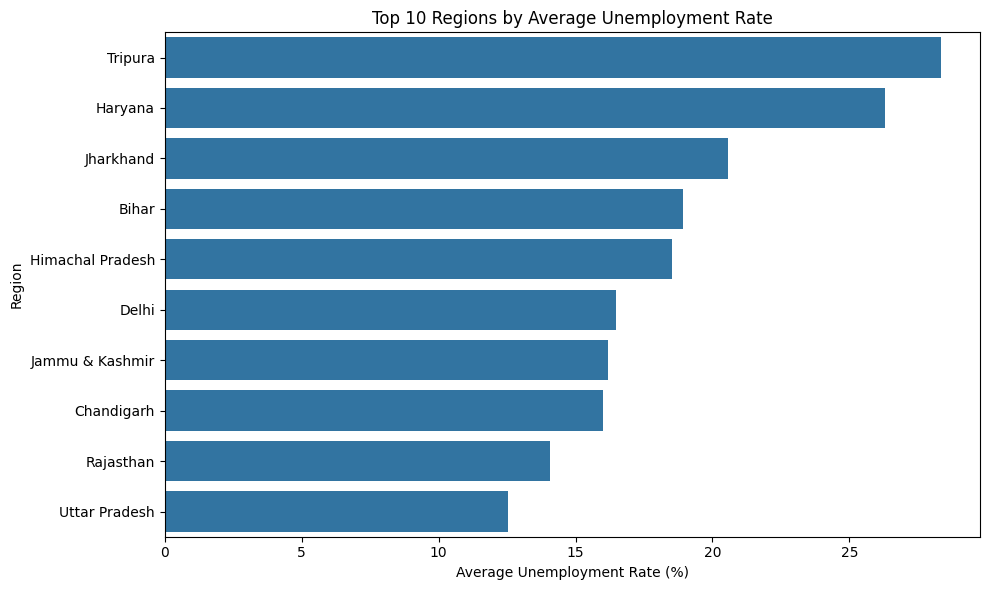

In [35]:
top_10_regions = region_unemployment.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_regions.values,
    y=top_10_regions.index
)

plt.title("Top 10 Regions by Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

### Observation

The bar chart shows the top 10 regions with the highest average
unemployment rates. These regions experienced comparatively higher
unemployment during the period covered by the dataset.

# Cell 11 — Monthly Average Unemployment

In [38]:
monthly_unemployment = (
    df.groupby(df["Date"].dt.to_period("M"))
    ["Estimated Unemployment Rate (%)"]
    .mean()
)

monthly_unemployment

Date
2019-05     8.874259
2019-06     9.303333
2019-07     9.033889
2019-08     9.637925
2019-09     9.051731
2019-10     9.900909
2019-11     9.868364
2019-12     9.497358
2020-01     9.950755
2020-02     9.964717
2020-03    10.700577
2020-04    23.641569
2020-05    24.875294
2020-06    11.903600
Freq: M, Name: Estimated Unemployment Rate (%), dtype: float64

# Cell 12 — Monthly Trend

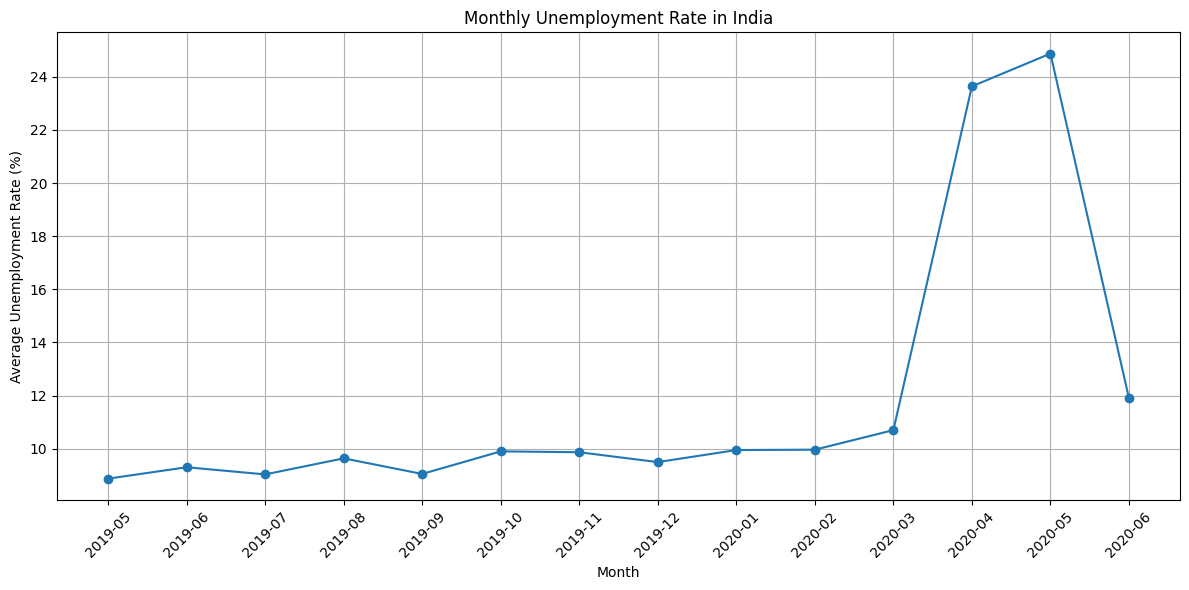

In [39]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_unemployment.index.astype(str),
    monthly_unemployment.values,
    marker="o"
)

plt.title("Monthly Unemployment Rate in India")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

### Observation

The monthly trend shows how India's average unemployment rate changed
over time. Peaks in the unemployment rate indicate periods of higher
unemployment.

# Cell 13 — Select 3 Regions

In [42]:
top_3_regions = (
    df.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
    .head(3)
    .index
)

print("Selected Regions:")
print(top_3_regions.tolist())

Selected Regions:
['Tripura', 'Haryana', 'Jharkhand']


# Cell 14 — Time-Series Chart

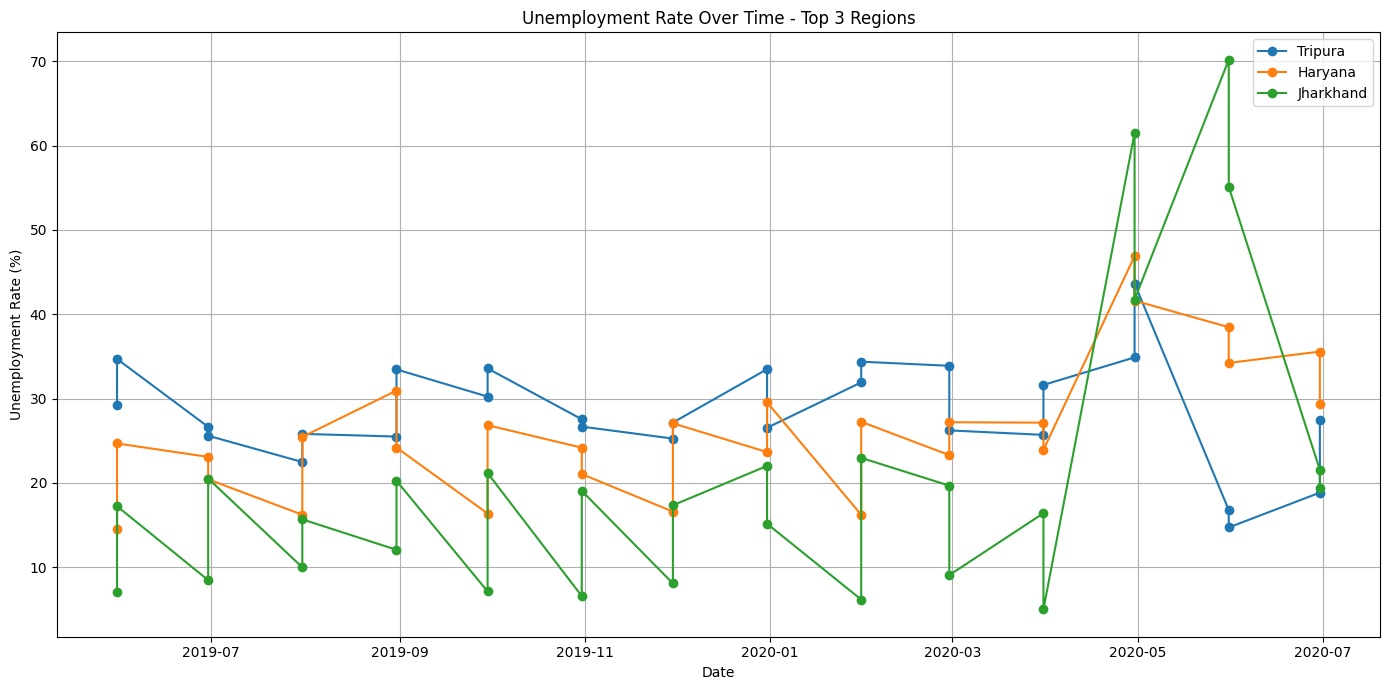

In [43]:
plt.figure(figsize=(14, 7))

for region in top_3_regions:
    region_data = df[df["Region"] == region].sort_values("Date")
    
    plt.plot(
        region_data["Date"],
        region_data["Estimated Unemployment Rate (%)"],
        marker="o",
        label=region
    )

plt.title("Unemployment Rate Over Time - Top 3 Regions")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Observation

The time-series chart compares unemployment trends across three
regions. It helps identify periods where unemployment increased or
decreased significantly in different regions.

# Cell 15 — Correlation Heatmap

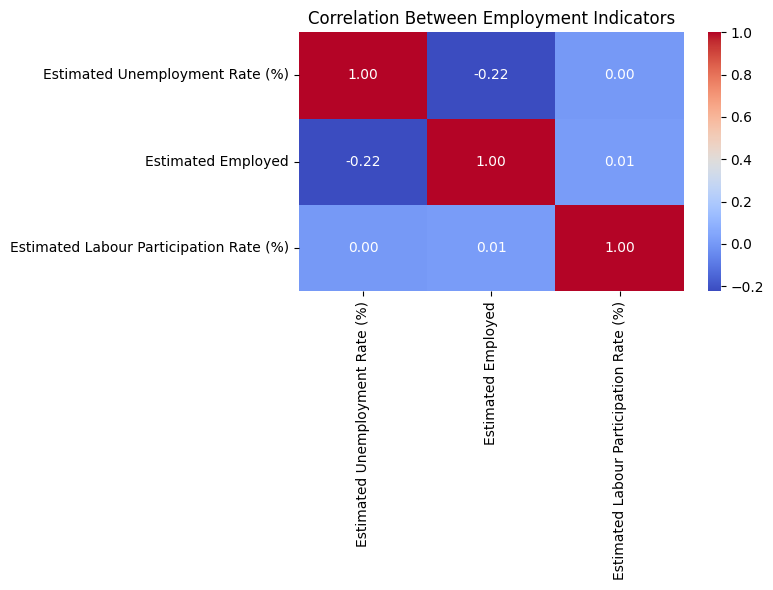

In [44]:
correlation_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Employment Indicators")

plt.tight_layout()
plt.show()

### Observation

The correlation heatmap shows the relationship between unemployment
rate, estimated employment, and labour participation rate.

Positive values indicate a positive relationship, while negative values
indicate an inverse relationship between the variables.

# Cell 16 — Define COVID Periods

In [45]:
covid_start = pd.Timestamp("2020-03-01")

df["COVID_Period"] = np.where(
    df["Date"] < covid_start,
    "Pre-COVID",
    "Post-COVID"
)

df["COVID_Period"].value_counts()

COVID_Period
Pre-COVID     536
Post-COVID    204
Name: count, dtype: int64

# Cell 17 — Compare Unemployment Rates

In [46]:
covid_comparison = (
    df.groupby("COVID_Period")
    ["Estimated Unemployment Rate (%)"]
    .mean()
)

print("Average Unemployment Rate:")
print(covid_comparison)

Average Unemployment Rate:
COVID_Period
Post-COVID    17.774363
Pre-COVID      9.509534
Name: Estimated Unemployment Rate (%), dtype: float64


# Cell 18 — COVID Comparison Chart

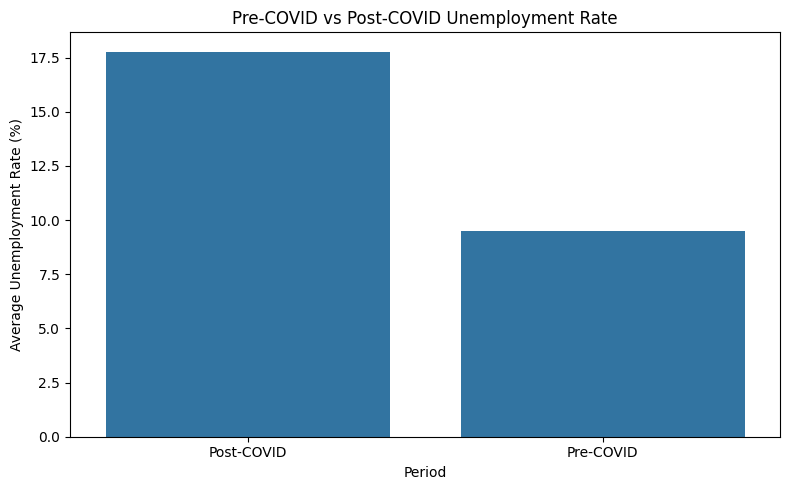

In [47]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=covid_comparison.index,
    y=covid_comparison.values
)

plt.title("Pre-COVID vs Post-COVID Unemployment Rate")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

plt.tight_layout()
plt.show()

### Observation

The comparison shows the difference in average unemployment rates
between the pre-COVID and post-COVID periods.

This analysis helps understand the change in unemployment associated
with the COVID-19 period.

### Observation

The comparison shows the difference in average unemployment rates
between the pre-COVID and post-COVID periods.

This analysis helps understand the change in unemployment associated
with the COVID-19 period.

# Cell 19 — Key Findings

## Key Findings

- The dataset contains unemployment information across different regions
  of India.
- Regional unemployment rates vary considerably.
- The monthly trend shows changes in unemployment over time.
- The top 10 regions with the highest average unemployment were identified.
- The correlation heatmap shows relationships between major employment
  indicators.
- Pre-COVID and post-COVID unemployment rates were compared to understand
  the impact of the COVID-19 period.

# Cell 20 — Final Conclusion

# Conclusion

The unemployment dataset was analyzed using Python, Pandas, Matplotlib,
and Seaborn.

The analysis covered data cleaning, exploratory data analysis,
regional unemployment comparison, monthly trends, time-series analysis,
correlation analysis, and pre-COVID versus post-COVID comparison.

The visualizations helped identify regional differences and changes in
unemployment over time.

Overall, this project demonstrates how exploratory data analysis can be
used to understand unemployment patterns and extract meaningful insights
from real-world data.

# Analysis of Dataset 2

## Load Dataset 2
## Dataset Inspection
## Data Cleaning
## Exploratory Data Analysis
## Regional Analysis
## Time-Series Analysis
## Correlation Analysis
## Geographic Information Analysis
## Key Observations

In [50]:
# Load Dataset 2

df2 = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

print("Dataset 2 loaded successfully!")
print("Shape:", df2.shape)

df2.head()

Dataset 2 loaded successfully!
Shape: (267, 9)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


# Step 1: Dataset 2

In [51]:
# Step 1: Clean Dataset 2 column names

df2.columns = df2.columns.str.strip()

print("Cleaned Column Names:")
print(df2.columns.tolist())

Cleaned Column Names:
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


# Step 2: Inspect Dataset 2

In [52]:
print("Dataset Shape:")
print(df2.shape)

print("\nData Types:")
print(df2.dtypes)

print("\nMissing Values:")
print(df2.isnull().sum())

print("\nFirst 5 Rows:")
display(df2.head())

Dataset Shape:
(267, 9)

Data Types:
Region                                      object
Date                                        object
Frequency                                   object
Estimated Unemployment Rate (%)            float64
Estimated Employed                           int64
Estimated Labour Participation Rate (%)    float64
Region.1                                    object
longitude                                  float64
latitude                                   float64
dtype: object

Missing Values:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64

First 5 Rows:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


# Step 3: Dataset 2 — Data Cleaning

In [53]:
# Step 3: Clean Dataset 2

# Remove completely empty rows
df2 = df2.dropna(how="all").reset_index(drop=True)

# Clean text columns
text_columns = ["Region", "Frequency", "Region.1"]

for column in text_columns:
    df2[column] = df2[column].astype("string").str.strip()

# Convert Date column
df2["Date"] = pd.to_datetime(
    df2["Date"],
    errors="coerce"
)

# Convert numerical columns
numeric_columns = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)",
    "longitude",
    "latitude"
]

for column in numeric_columns:
    df2[column] = pd.to_numeric(
        df2[column],
        errors="coerce"
    )

print("Dataset 2 cleaning completed!")
print("Shape:", df2.shape)

Dataset 2 cleaning completed!
Shape: (267, 9)


C:\Users\Rohit singh\AppData\Local\Temp\ipykernel_4328\3684528620.py:13: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df2["Date"] = pd.to_datetime(


# Step 4: Check Missing Values

In [54]:
print("Missing Values After Cleaning:")

missing_values = df2.isnull().sum()

print(missing_values)

Missing Values After Cleaning:
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64


# # Step 5: Descriptive Statistics

In [55]:
df2.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,2020-06-16 09:15:30.337078528,12.236929,1.396211e+07,41.681573,22.826048,80.532425
min,2020-01-31 00:00:00,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,2020-03-31 00:00:00,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,2020-06-30 00:00:00,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,2020-08-31 00:00:00,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,2020-10-31 00:00:00,75.850000,5.943376e+07,69.690000,33.778200,92.937600
std,NaN,10.803283,1.336632e+07,7.845419,6.270731,5.831738


# Step 6: Region-wise Average Unemployment Rate

In [56]:
region_unemployment_2 = (
    df2.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Unemployment Rate by Region:")
print(region_unemployment_2)

Average Unemployment Rate by Region:
Region
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Goa                 12.167000
Punjab              11.981000
Uttarakhand         11.156000
West Bengal         10.192000
Sikkim               9.792500
Uttar Pradesh        9.737000
Kerala               9.434000
Andhra Pradesh       8.664000
Maharashtra          7.979000
Chhattisgarh         7.819000
Karnataka            7.668000
Madhya Pradesh       6.854000
Telangana            6.833000
Odisha               6.462000
Gujarat              6.376000
Assam                4.856000
Meghalaya            3.866000
Name: Estimated Unemployment Rate (%), dtype: float64


# Step 7: Top 10 Regions — Bar Chart

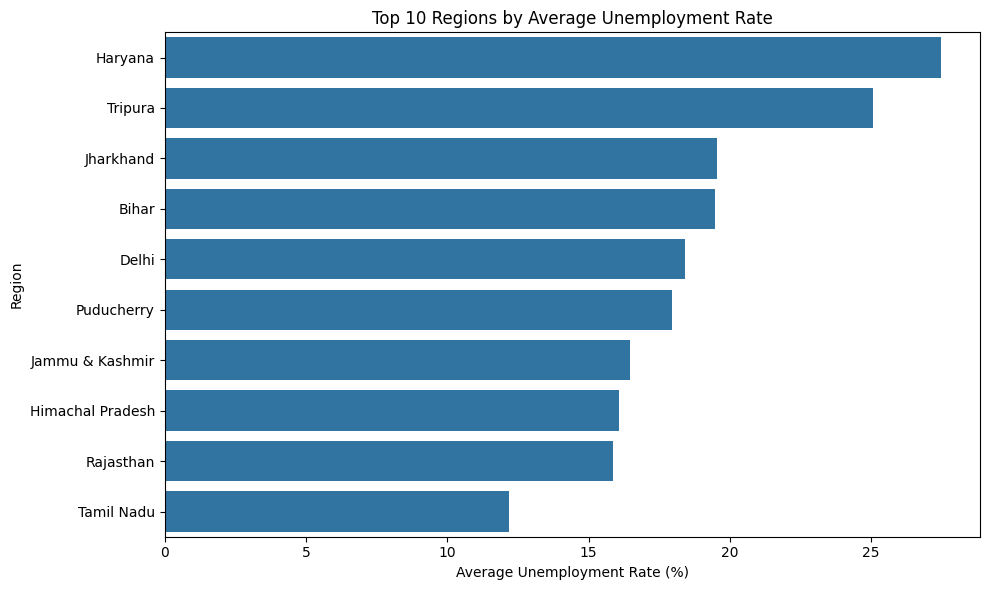

In [57]:
top_10_regions_2 = region_unemployment_2.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_regions_2.values,
    y=top_10_regions_2.index
)

plt.title("Top 10 Regions by Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

# Step 8: Month-wise Average Unemployment Rate

In [58]:
# Step 8: Month-wise Average Unemployment Rate

monthly_unemployment_2 = (
    df2.groupby(df2["Date"].dt.to_period("M"))
    ["Estimated Unemployment Rate (%)"]
    .mean()
)

print("Monthly Average Unemployment Rate:")
print(monthly_unemployment_2)

Monthly Average Unemployment Rate:
Date
2020-01     9.196538
2020-02     9.266154
2020-03    10.782593
2020-04    22.236154
2020-05    23.244444
2020-06    10.911111
2020-07     9.834444
2020-08    10.313333
2020-09     8.705926
2020-10     8.026296
Freq: M, Name: Estimated Unemployment Rate (%), dtype: float64


# Step 9: Monthly Unemployment Trend — Line Chart

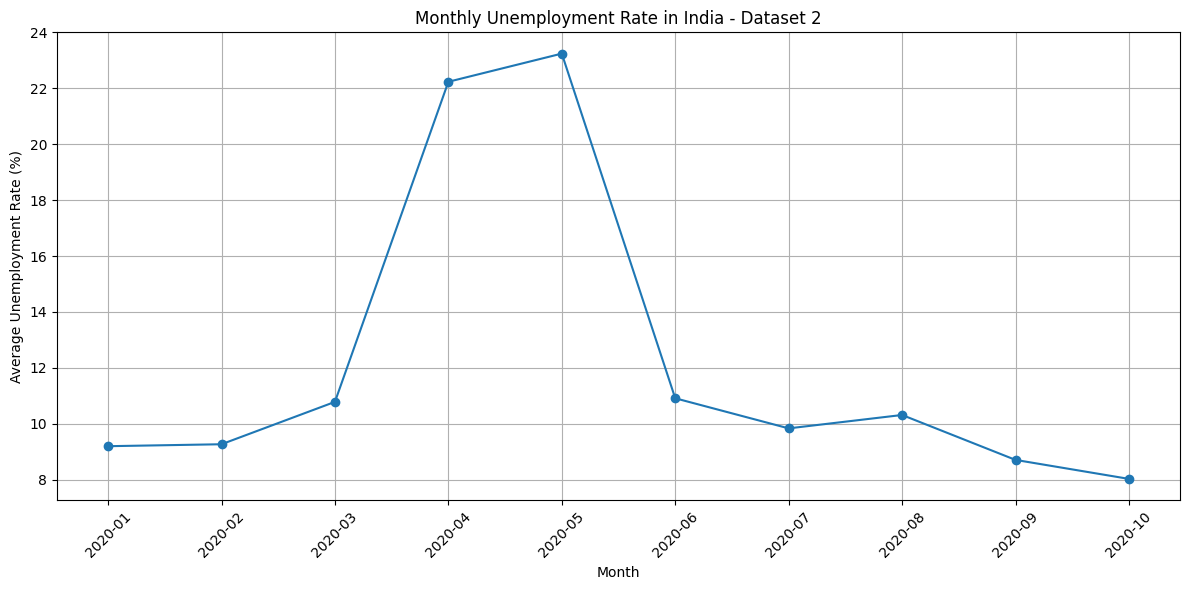

In [59]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_unemployment_2.index.astype(str),
    monthly_unemployment_2.values,
    marker="o"
)

plt.title("Monthly Unemployment Rate in India - Dataset 2")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

# Step 10: Select Top 3 Regions

In [60]:
# Step 10: Select Top 3 Regions

top_3_regions_2 = (
    df2.groupby("Region")["Estimated Unemployment Rate (%)"]
    .mean()
    .sort_values(ascending=False)
    .head(3)
    .index
)

print("Top 3 Regions:")
print(top_3_regions_2.tolist())

Top 3 Regions:
['Haryana', 'Tripura', 'Jharkhand']


# Step 11: Top 3 Regions Time-Series Chart

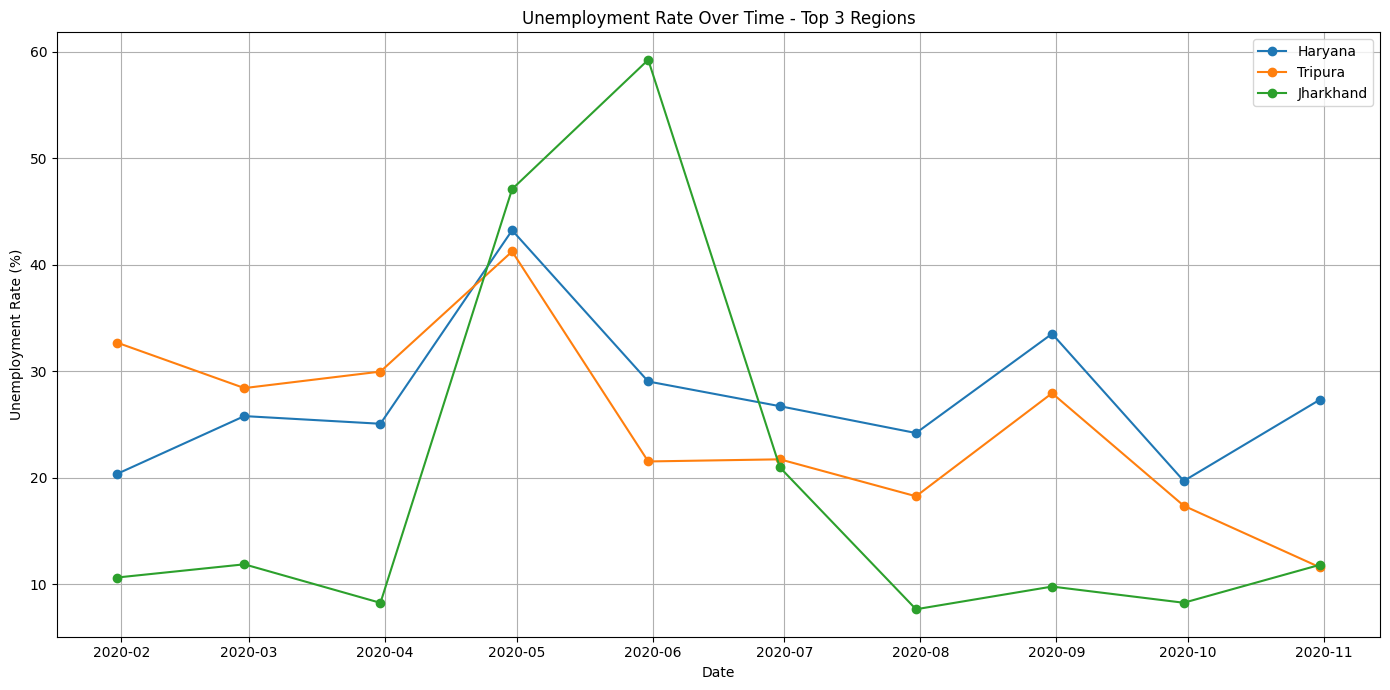

In [61]:
# Step 11: Unemployment Trend of Top 3 Regions

plt.figure(figsize=(14, 7))

for region in top_3_regions_2:
    region_data = (
        df2[df2["Region"] == region]
        .sort_values("Date")
    )
    
    plt.plot(
        region_data["Date"],
        region_data["Estimated Unemployment Rate (%)"],
        marker="o",
        label=region
    )

plt.title("Unemployment Rate Over Time - Top 3 Regions")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# tep 12: Correlation Analysis

In [63]:
correlation_columns_2 = [
    "Estimated Unemployment Rate (%)",
    "Estimated Employed",
    "Estimated Labour Participation Rate (%)"
]

correlation_matrix_2 = df2[correlation_columns_2].corr()

print(correlation_matrix_2)

                                         Estimated Unemployment Rate (%)  \
Estimated Unemployment Rate (%)                                 1.000000   
Estimated Employed                                             -0.245176   
Estimated Labour Participation Rate (%)                        -0.073540   

                                         Estimated Employed  \
Estimated Unemployment Rate (%)                   -0.245176   
Estimated Employed                                 1.000000   
Estimated Labour Participation Rate (%)           -0.047948   

                                         Estimated Labour Participation Rate (%)  
Estimated Unemployment Rate (%)                                        -0.073540  
Estimated Employed                                                     -0.047948  
Estimated Labour Participation Rate (%)                                 1.000000  


# Step 13: Correlation Heatmap

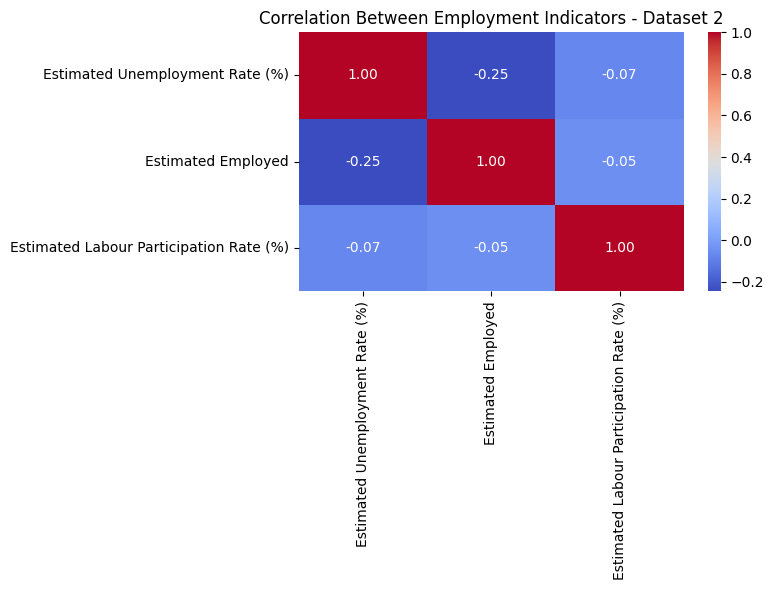

In [64]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix_2,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Employment Indicators - Dataset 2")
plt.tight_layout()
plt.show()

# Step 14: Create COVID Period

In [65]:
covid_start = pd.Timestamp("2020-03-01")

df2["COVID_Period"] = np.where(
    df2["Date"] < covid_start,
    "Pre-COVID",
    "Post-COVID"
)

print(df2["COVID_Period"].value_counts())

COVID_Period
Post-COVID    215
Pre-COVID      52
Name: count, dtype: int64


# Step 15: Pre-COVID vs Post-COVID Average

In [66]:
covid_comparison_2 = (
    df2.groupby("COVID_Period")
    ["Estimated Unemployment Rate (%)"]
    .mean()
)

print("Average Unemployment Rate:")
print(covid_comparison_2)

Average Unemployment Rate:
COVID_Period
Post-COVID    12.963860
Pre-COVID      9.231346
Name: Estimated Unemployment Rate (%), dtype: float64


# Step 16: COVID Comparison Chart

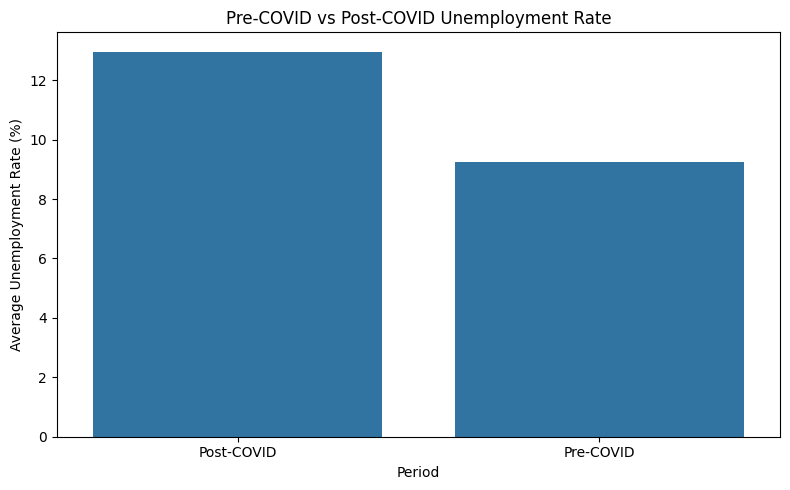

In [67]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=covid_comparison_2.index,
    y=covid_comparison_2.values
)

plt.title("Pre-COVID vs Post-COVID Unemployment Rate")
plt.xlabel("Period")
plt.ylabel("Average Unemployment Rate (%)")

plt.tight_layout()
plt.show()

# Step 17: Geographic Analysis

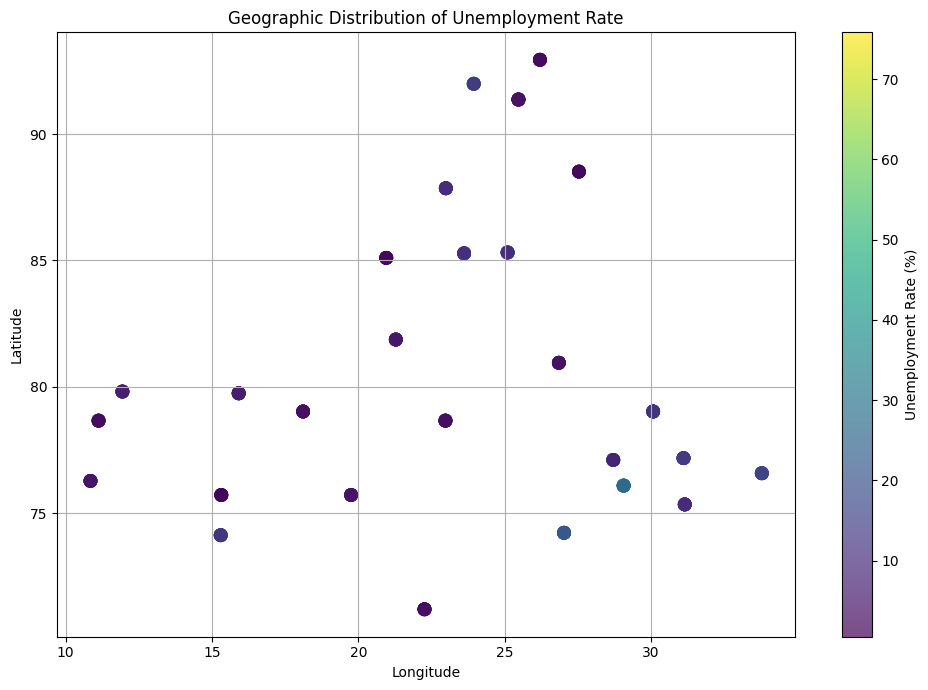

In [68]:
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    df2["longitude"],
    df2["latitude"],
    c=df2["Estimated Unemployment Rate (%)"],
    s=80,
    alpha=0.7,
    cmap="viridis"
)

plt.colorbar(scatter, label="Unemployment Rate (%)")

plt.title("Geographic Distribution of Unemployment Rate")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.grid(True)
plt.tight_layout()
plt.show()

# Step 18: Region-wise Summary Table

In [69]:
region_summary_2 = (
    df2.groupby("Region")
    .agg(
        Average_Unemployment_Rate=(
            "Estimated Unemployment Rate (%)",
            "mean"
        ),
        Average_Employed=(
            "Estimated Employed",
            "mean"
        ),
        Average_Labour_Participation=(
            "Estimated Labour Participation Rate (%)",
            "mean"
        )
    )
    .sort_values(
        "Average_Unemployment_Rate",
        ascending=False
    )
)

region_summary_2

,Average_Unemployment_Rate,Average_Employed,Average_Labour_Participation
Region,,,
Haryana,27.477000,6.844059e+06,42.100000
Tripura,25.055000,1.397292e+06,57.848000
Jharkhand,19.539000,8.770642e+06,40.356000
Bihar,19.471000,2.360683e+07,37.173000
Delhi,18.414000,4.632822e+06,35.857000
Puducherry,17.942000,3.652629e+05,35.918000
Jammu & Kashmir,16.477778,3.310032e+06,37.894444
Himachal Pradesh,16.065000,2.033885e+06,40.252000
Rajasthan,15.868000,1.973175e+07,40.591000


# Step 19: Dataset 2 Key Findings

## Key Findings - Dataset 2

- The dataset contains unemployment information for different regions of India during 2020.
- The average unemployment rate varies considerably across regions.
- The monthly trend shows changes in unemployment rates during the year.
- Some regions experienced higher average unemployment rates than others.
- The correlation analysis helps identify relationships between unemployment, employment, and labour participation.
- The Pre-COVID and Post-COVID comparison helps understand changes in unemployment after the beginning of the COVID-19 period.
- The geographic visualization shows how unemployment observations are distributed across different locations.

# Step 20: Dataset 2 Conclusion

## Conclusion - Dataset 2

The analysis of Dataset 2 provides insights into unemployment patterns
across different regions of India during 2020.

Region-wise analysis shows variation in unemployment rates across
different regions. Monthly trend analysis helps identify changes in
unemployment over time, while the correlation heatmap provides an
understanding of relationships among unemployment, employment, and
labour participation indicators.

The Pre-COVID and Post-COVID comparison provides additional insight
into unemployment conditions during the COVID-19 period.

Overall, the analysis demonstrates how Python, Pandas, Matplotlib,
and Seaborn can be used to explore and visualize unemployment data.

# Step 21: Compare Dataset 1 and Dataset 2

In [71]:
comparison = pd.DataFrame({
    "Dataset": ["Dataset 1", "Dataset 2"],
    
    "Number of Records": [
        len(df),
        len(df2)
    ],
    
    "Average Unemployment Rate (%)": [
        df["Estimated Unemployment Rate (%)"].mean(),
        df2["Estimated Unemployment Rate (%)"].mean()
    ],
    
    "Average Employed": [
        df["Estimated Employed"].mean(),
        df2["Estimated Employed"].mean()
    ],
    
    "Average Labour Participation Rate (%)": [
        df["Estimated Labour Participation Rate (%)"].mean(),
        df2["Estimated Labour Participation Rate (%)"].mean()
    ]
})

comparison

,Dataset,Number of Records,Average Unemployment Rate (%),Average Employed,Average Labour Participation Rate (%)
0,Dataset 1,740,11.787946,7.204460e+06,42.630122
1,Dataset 2,267,12.236929,1.396211e+07,41.681573


# Step 22: Final Key Findings

### Dataset 1
- The dataset contains 740 valid observations after removing completely empty rows.
- Regional analysis shows variation in average unemployment rates across different regions.
- Monthly analysis helps identify changes in unemployment rates over time.
- The correlation analysis shows the relationship between unemployment, employment, and labour participation indicators.
- The Pre-COVID and Post-COVID comparison provides insights into changes in unemployment during the COVID-19 period.

### Dataset 2
- The dataset contains 267 observations with additional geographical information such as longitude and latitude.
- Average unemployment rates vary across different regions.
- Monthly trends show changes in unemployment during 2020.
- The correlation analysis provides insights into relationships among unemployment, employment, and labour participation.
- Geographic visualization helps understand the spatial distribution of unemployment observations.

### Overall Observation
Both datasets provide useful insights into unemployment patterns in India.
Dataset 1 provides a broader set of observations, while Dataset 2 provides
additional geographical information for 2020.

Python, Pandas, Matplotlib, and Seaborn were used for data cleaning,
exploratory data analysis, statistical analysis, and visualization.

# Step 23: Final Conclusion

## Conclusion

This project analyzed unemployment data in India using two related
datasets. The analysis covered data cleaning, descriptive statistics,
regional unemployment analysis, monthly trends, correlation analysis,
COVID-19 period comparison, and geographical visualization.

The project demonstrates how exploratory data analysis can be used to
identify unemployment patterns and understand relationships between
different employment indicators.

The analysis was performed using Python with Pandas, NumPy,
Matplotlib, and Seaborn in Jupyter Notebook.